In [226]:
#First of all I opened a file 
import pandas as pd

import csv
csv.field_size_limit(100000000)  # Increased the limit

df = pd.read_csv("test_sample.csv", engine='python', on_bad_lines='skip')

df.head()

,platform,account_id,id,created_time,text_original,text_additional,likes_count,shares_count,comments_count,views_count
0,Instagram,59141296785,C_00PPctR-o,2024-09-12 17:20:36.000000 +00:00,NaN,NaN,222.0,NaN,34.0,NaN
1,Instagram,60554087008,C_00W8KttVv,2024-09-12 17:21:27.000000 +00:00,C’è un gruppo sulla parola di Dio sulla mia ho...,NaN,391.0,NaN,37.0,NaN
2,Instagram,62605500679,C_026U_t3We,2024-09-12 17:43:38.000000 +00:00,𝐒𝐮𝐥 𝐦𝐢𝐨 𝐩𝐫𝐨𝐟𝐢𝐥𝐨 𝐜‘𝐞̀ 𝐮𝐧 𝐠𝐫𝐮𝐩𝐩𝐨 𝐝𝐢 𝐬𝐭𝐮𝐝𝐢𝐨 𝐬𝐮𝐥𝐥𝐚...,NaN,9.0,NaN,3.0,NaN
3,Instagram,58741537308,C_05B3hCYQn,2024-09-12 18:02:08.000000 +00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,78.0,NaN,15.0,NaN
4,Instagram,58741537308,C_0BfOLiqRS,2024-09-12 09:57:22.000000 +00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,129.0,NaN,16.0,NaN


In [228]:
# I used df.info() to understand the structure of the dataset, the data types, and the number of missing values in each field.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10525 entries, 0 to 10524
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10525 non-null  object 
 1   account_id       10000 non-null  object 
 2   id               10047 non-null  object 
 3   created_time     10000 non-null  object 
 4   text_original    7660 non-null   object 
 5   text_additional  3 non-null      object 
 6   likes_count      9951 non-null   float64
 7   shares_count     5000 non-null   float64
 8   comments_count   9908 non-null   float64
 9   views_count      5621 non-null   float64
dtypes: float64(4), object(6)
memory usage: 822.4+ KB


In [230]:
 #Then I counted the absolute number of missing values in each column to understand which fields are the most affected.
df.isna().sum()

platform               0
account_id           525
id                   478
created_time         525
text_original       2865
text_additional    10522
likes_count          574
shares_count        5525
comments_count       617
views_count         4904
dtype: int64

In [232]:
#I also converted the number of missing values into percentages to correctly compare the columns with each other.
(df.isna().mean() * 100).round(1) 

platform             0.0
account_id           5.0
id                   4.5
created_time         5.0
text_original       27.2
text_additional    100.0
likes_count          5.5
shares_count        52.5
comments_count       5.9
views_count         46.6
dtype: float64

In [234]:
#Before starting the analysis, I checked the data quality by examining missing values across all columns.
#I found that some engagement metrics such as views and shares were missing for a significant portion of the data,likely due to platform-specific limitations.
#This was taken into account during further analysis.
missing = pd.DataFrame({    
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(1)
}).sort_values("missing_percent", ascending=False)

missing

,missing_count,missing_percent
text_additional,10522,100.0
shares_count,5525,52.5
views_count,4904,46.6
text_original,2865,27.2
comments_count,617,5.9
likes_count,574,5.5
account_id,525,5.0
created_time,525,5.0
id,478,4.5
platform,0,0.0


In [236]:
#I removed columns that contained no useful information, such as text_additional, which was completely empty.
if 'text_additional' in df.columns:
    df = df.drop(columns=['text_additional'])

In [237]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10525 entries, 0 to 10524
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   platform        10525 non-null  object 
 1   account_id      10000 non-null  object 
 2   id              10047 non-null  object 
 3   created_time    10000 non-null  object 
 4   text_original   7660 non-null   object 
 5   likes_count     9951 non-null   float64
 6   shares_count    5000 non-null   float64
 7   comments_count  9908 non-null   float64
 8   views_count     5621 non-null   float64
dtypes: float64(4), object(5)
memory usage: 740.2+ KB


In [239]:
#I converted the publication time to datetime format to enable time-based analysis, such as trends over time.
df['created_time'] = pd.to_datetime(df['created_time'], errors='coerce')

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10525 entries, 0 to 10524
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   platform        10525 non-null  object             
 1   account_id      10000 non-null  object             
 2   id              10047 non-null  object             
 3   created_time    10000 non-null  datetime64[ns, UTC]
 4   text_original   7660 non-null   object             
 5   likes_count     9951 non-null   float64            
 6   shares_count    5000 non-null   float64            
 7   comments_count  9908 non-null   float64            
 8   views_count     5621 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(4), object(4)
memory usage: 740.2+ KB


In [242]:
#I also checked the dataset for duplicate rows to ensure data integrity.
df.duplicated().sum()

415

In [244]:
#Engagement metrics have highly skewed distributions, which is typical for social media data.
df[['likes_count', 'comments_count', 'shares_count', 'views_count']].describe()

,likes_count,comments_count,shares_count,views_count
count,9951.000000,9908.000000,5000.000000,5.621000e+03
mean,1414.377851,299.861122,79.232000,1.797353e+04
std,5989.211037,1259.439901,979.564848,1.012492e+05
min,0.000000,0.000000,0.000000,3.000000e+00
25%,116.000000,28.000000,3.000000,1.539000e+03
50%,354.000000,93.000000,9.000000,3.704000e+03
75%,895.000000,261.000000,43.000000,8.535000e+03
max,188611.000000,80415.000000,47500.000000,3.500000e+06


In [246]:
#If the 99th percentile is much higher than the 90th, there are outliers.
df[['likes_count', 'comments_count']].quantile([0.5, 0.9, 0.99])

,likes_count,comments_count
0.50,354.0,93.00
0.90,2254.0,641.30
0.99,21862.5,2863.88


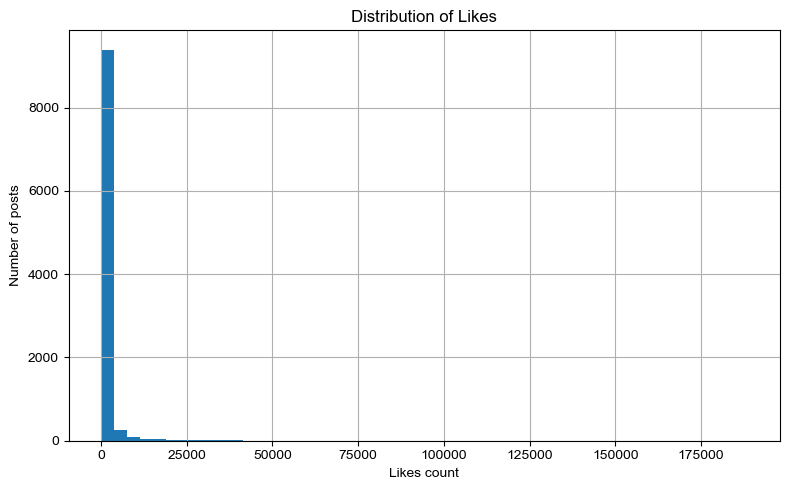

In [299]:
# Likes distribution is analyzed on raw data without normalization, as likes represent absolute engagement volume.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
df['likes_count'].dropna().hist(bins=50)
plt.title('Distribution of Likes')
plt.xlabel('Likes count')
plt.ylabel('Number of posts')
plt.tight_layout()
plt.savefig('eda_images/likes_distribution.png', dpi=300)
plt.show()

In [250]:
#Since absolute engagement metrics are not directly comparable across posts, I calculated engagement rate to normalize interaction by reach.
df['engagement'] = (
    df['likes_count'].fillna(0) +
    df['comments_count'].fillna(0) +
    df['shares_count'].fillna(0)
) / df['views_count']

In [252]:
# Sanity check: verify engagement calculation and missing values
df_er[['likes_count', 'comments_count', 'shares_count', 'views_count', 'engagement']].head()

,likes_count,comments_count,shares_count,views_count,engagement
3025,799.0,320.0,48.0,6979.0,0.167216
3026,409.0,20.0,72.0,4634.0,0.108114
3027,163.0,29.0,18.0,1718.0,0.122235
3028,1948.0,994.0,74.0,14200.0,0.212394
3029,2950.0,650.0,570.0,32800.0,0.127134


In [280]:
#Engagement rate was calculated only for posts with available view counts to avoid misleading results.
df_er = df.loc[df['views_count'].notna()].copy()

In [282]:
#After filtering, there are no missing values in views_count in the engagement dataset.
df_er['views_count'].isna().sum()

0

In [284]:
#I started by checking the distribution of posts across platforms to ensure meaningful comparisons.
df['platform'].value_counts()

platform
Instagram                                                                2500
TikTok                                                                   2500
Facebook                                                                 2500
YouTube                                                                  2500
#preghieradelcuore                                                         26
                                                                         ... 
#Chiesa                                                                     1
#BasilicadiSanFrancesco                                                     1
#BasilicadiSantaMariaaPugliano #gesù #preghire                              1
#lourdes                                                                    1
Unisciti al gruppo Whatsapp sulla mia home page per dirti la risposta       1
Name: count, Length: 79, dtype: int64

In [286]:
#Due to heavy skewness and outliers, I used median values to compare engagement across platforms.
df.groupby('platform')['likes_count'].median().sort_values(ascending=False)

platform
TikTok                                                                           663.0
Instagram                                                                        408.0
YouTube                                                                          353.5
Facebook                                                                         135.5
 #Gesùtiamo                                                                        NaN
                                                                                 ...  
Il clink del  gruppo può essere trovato nel mio profilo. Leggi le istruzioni+      NaN
Il link del gruppo può essere trovato nel mio profilo.                             NaN
Il link del gruppo può essere trovato nel mio profilo. Leggi le istruzioni+        NaN
Leggi la descrizione per saperne di più+                                           NaN
Unisciti al gruppo Whatsapp sulla mia home page per dirti la risposta              NaN
Name: likes_count, Length: 79, dty

In [288]:
#I compared platforms using median engagement rate, which normalizes interaction by reach and allows fair comparison.
df.groupby('platform')['comments_count'].median().sort_values(ascending=False)

platform
Facebook                                                                         202.5
TikTok                                                                           121.0
Instagram                                                                         70.0
YouTube                                                                           44.0
 #Gesùtiamo                                                                        NaN
                                                                                 ...  
Il clink del  gruppo può essere trovato nel mio profilo. Leggi le istruzioni+      NaN
Il link del gruppo può essere trovato nel mio profilo.                             NaN
Il link del gruppo può essere trovato nel mio profilo. Leggi le istruzioni+        NaN
Leggi la descrizione per saperne di più+                                           NaN
Unisciti al gruppo Whatsapp sulla mia home page per dirti la risposta              NaN
Name: comments_count, Length: 79, 

In [289]:
df_er.groupby('platform')['engagement'].median().sort_values(ascending=False)

platform
Facebook    0.294964
TikTok      0.164248
YouTube     0.139481
Name: engagement, dtype: float64

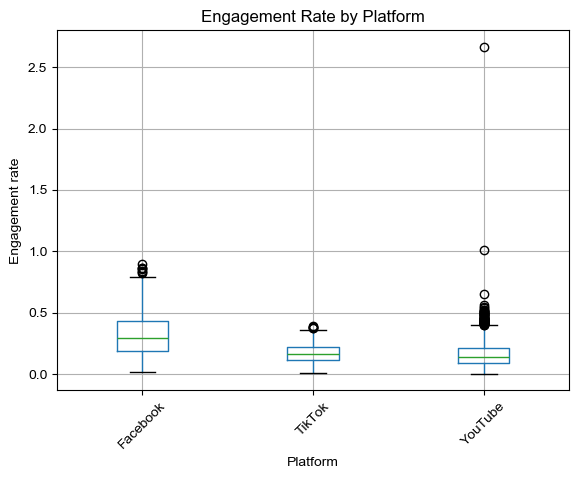

In [291]:
# Engagement rate is calculated only for posts with available views_count to ensure meaningful normalization.
df_er.boxplot(column='engagement', by='platform', rot=45)
plt.title('Engagement Rate by Platform')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Engagement rate')
plt.savefig("likes_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

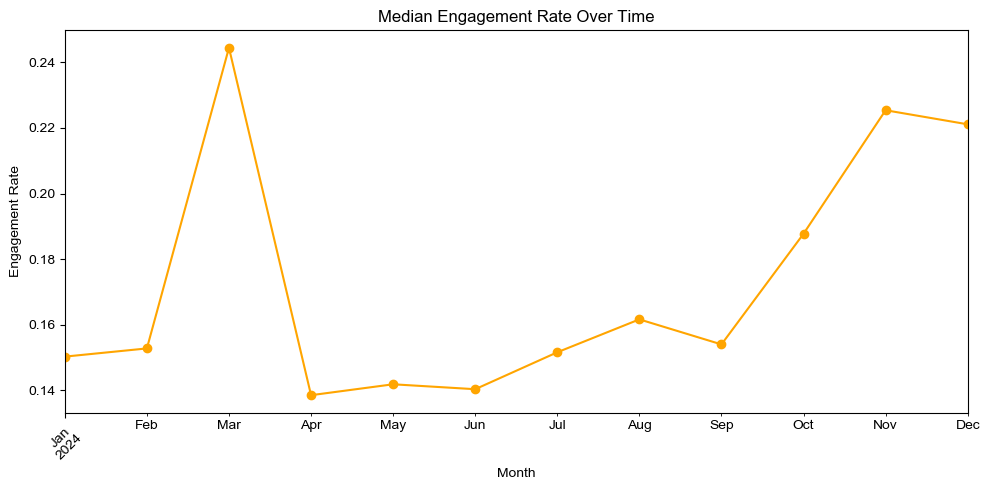

In [304]:
# created_time was converted to datetime and aggregated at monthly level to reduce noise and highlight temporal patterns.
df['created_time'] = pd.to_datetime(df['created_time']).dt.tz_localize(None)
df['year_month'] = df['created_time'].dt.to_period('M')

# Group by month and calculate median engagement
monthly_engagement = df.groupby('year_month')['engagement'].median()

plt.figure(figsize=(10,5))
monthly_engagement.plot(marker='o', color='orange')
plt.title('Median Engagement Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_images/median_engagement_over_time.png', dpi=300)
plt.show()

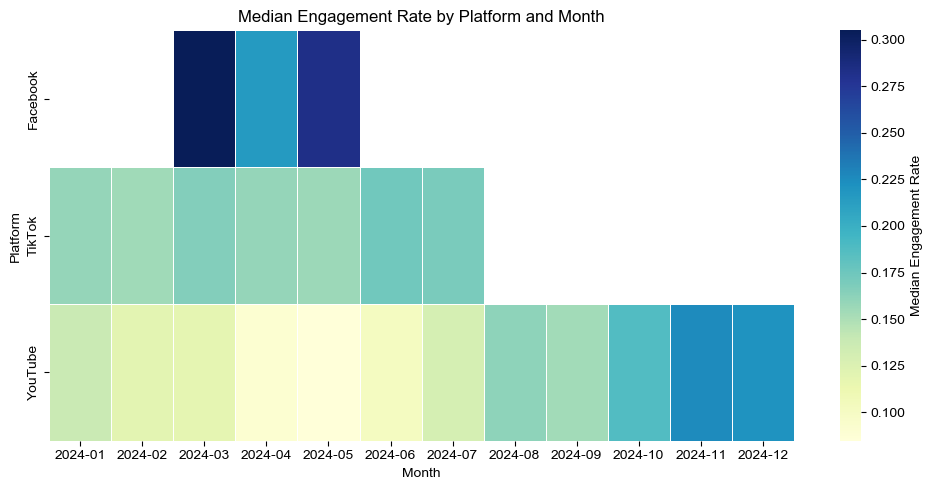

In [298]:
# Median engagement is used instead of mean to reduce the impact of extreme outliers.
heatmap_data = (
    df_er
    .groupby(['platform', 'year_month'])['engagement']
    .median()
    .unstack()
    .sort_index(axis=1)
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5,
    mask=heatmap_data.isna(),
    cbar_kws={'label': 'Median Engagement Rate'}
)

plt.title('Median Engagement Rate by Platform and Month')
plt.xlabel('Month')
plt.ylabel('Platform')
plt.tight_layout()
plt.savefig('eda_images/correlation_heatmap.png', dpi=300)
plt.show()

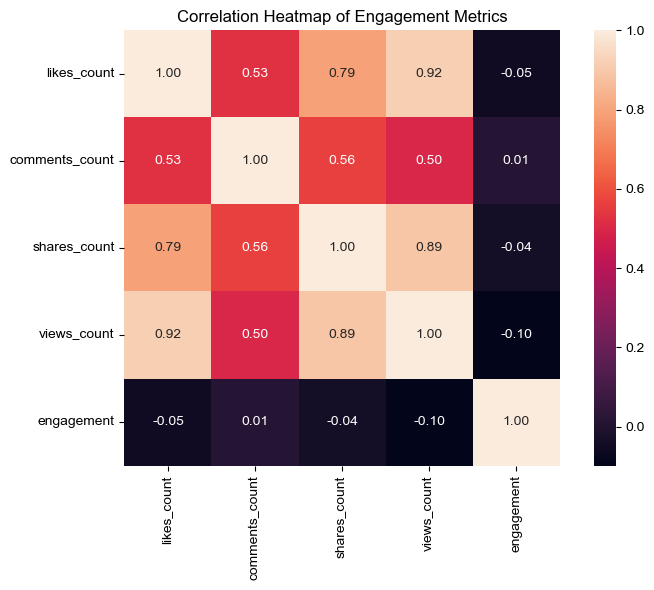

In [295]:
# Correlation analysis is performed on numeric engagement metrics only.
numeric_cols = [
    'likes_count',
    'comments_count',
    'shares_count',
    'views_count',
    'engagement'
]

corr = df_er[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.tight_layout()
plt.savefig('eda_images/correlation_heatmap.png', dpi=300)
plt.show()

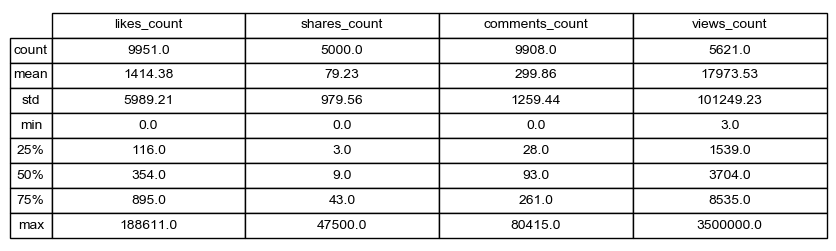

In [296]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs('eda_images', exist_ok=True)
data_overview = df[['likes_count', 'shares_count', 'comments_count', 'views_count']].describe().round(2)

fig, ax = plt.subplots(figsize=(10, 3))  # ширина x высота
ax.axis('off')  # отключаем оси

table = ax.table(
    cellText=data_overview.values,
    colLabels=data_overview.columns,
    rowLabels=data_overview.index,
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  

plt.savefig('eda_images/data_overview_table.png', dpi=300, bbox_inches='tight')
plt.show()


In [272]:
#1. Engagement metrics are highly right-skewed, with a small number of posts driving the majority of interactions.
#2. Views count contains a substantial amount of missing values, which limits the scope of engagement rate analysis.
#3. Normalized engagement rate enables fair comparison across posts with different audience sizes.
#4. Median engagement rates vary across platforms, with noticeable differences in distribution and variability.
#5. Engagement over time shows moderate month-to-month fluctuations without a strong seasonal trend.
#6. Platform-level engagement patterns differ over time, as highlighted by the platform-by-month heatmap.
#7. Likes, comments, and shares are strongly correlated, while views exhibit weaker correlation with interaction metrics.
#8. Missing views and shares data may bias platform-level comparisons and should be addressed before deeper modeling.
#9. Overall, the dataset is suitable for exploratory analysis, but improved data completeness would enhance analytical reliability.